In [1]:
import numpy as np
from pathlib import Path
from define_data_and_variables import HMCConfig, Data, hmc_config, data, c_data, dict_to_struct, make_dumpable, hash_configs, name_map
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
import os

{'N': 50, 'nc14': 8, 'nd18o': 300, 'nd18or': 1000, 'H': 100, 'dc': 2.0, 'pm': 1.71472, 'ps': 0.7107, 'th': np.float64(1983.0), 'cs': array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
        22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
        44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
        66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
        88.,  90.,  92.,  94.,  96.,  98., 100.]), 'c14': array([1970., 1836., 1787., 1660., 1559., 1512., 1278., 1271.]), 'c14d': array([ 2.5 , 27.75, 35.25, 54.  , 72.5 , 78.75, 96.75, 98.  ]), 'c14s': array([0.5, 1. , 1. , 1.5, 2. , 1.5, 2.5, 4. ]), 'ic14v': array([4.        , 1.        , 1.        , 0.44444444, 0.25      ,
       0.44444444, 0.16      , 0.0625    ]), 'd18o': array([-8.88345608, -8.64959204, -8.62935534, -8.48353373, -8.30041378,
       -8.48950889, -8.46032581, -8.35108925, -8.53669888, -8.4617046 ,
       -8.64683185, -8.50141088, -8.50987652, -8.

In [4]:
base_dir = Path.cwd()
np.random.seed(hmc_config["sd"])
sp = np.random.multivariate_normal(data["pm"]* np.ones(data["N"]), data["ps"]**2 * np.eye(data["N"]), (hmc_config["nch"]))
sp = np.exp(sp)
hmc_config["sp"] = np.ascontiguousarray(sp)
print(sp)
hmc_hash = hash_configs(hmc_config, data)
output_dir = base_dir / f"output/{data["dn"]}/{hmc_hash}"
print(output_dir)
samples = np.load(output_dir / "samples.npy")[:, 2000:, :]

np.random.seed(2)
samples_1 = samples.reshape(-1, samples.shape[-1])[
    np.random.randint(samples.shape[0] * samples.shape[1])
]

# np.random.seed(59)
# samples_2 = samples.reshape(-1, samples.shape[-1])[
#     np.random.randint(samples.shape[0] * samples.shape[1])
# ]

# np.random.seed(101)
# samples_3 = samples.reshape(-1, samples.shape[-1])[
#     np.random.randint(samples.shape[0] * samples.shape[1])
# ]
cumulative_sums_1 = np.cumsum(samples_1) * data["dc"]
# cumulative_sums_2 = np.cumsum(samples_2) * data["dc"]
# cumulative_sums_3 = np.cumsum(samples_3) * data["dc"]
# zeros = np.zeros((*sp.shape[:1], 1))
age_offsets_1 = np.concatenate((np.array([0]), cumulative_sums_1))
model_ages_1 = data["th"] - age_offsets_1
# age_offsets_2 = np.concatenate((np.array([0]), cumulative_sums_2))
# model_ages_2 = data["th"] - age_offsets_2
# age_offsets_3 = np.concatenate((np.array([0]), cumulative_sums_3))
# model_ages_3 = data["th"] - age_offsets_3

[[ 7.90689172  5.03521165  8.80246894 16.39763831  4.70350134  4.70355622
  17.06563083  9.58439123  3.97913538  8.16876245  3.99630045  3.9897392
   6.59744588  1.42611181  1.63039268  3.72513187  2.70445638  6.94523338
   2.91359376  2.03601763 15.74238223  4.73158756  5.82822384  2.01808989
   3.77283685  6.01076894  2.45152153  7.25527348  3.62497026  4.51503641
   3.62222005 20.72071875  5.50208726  2.61955601  9.96722957  2.33279336
   6.44406374  1.37986055  2.16144758  6.38932916  9.38908832  6.27461066
   5.11679755  4.48494218  1.94241962  3.33051425  4.00420086 11.77544895
   7.09173143  1.58681262]
 [ 6.99395691  4.22509617  3.43367644  8.58003797 11.55884981 10.76802162
   3.05961199  4.45917051  7.02973438 11.11215908  3.95179881  4.86843322
   2.530578    2.37399918  9.89650933 14.56468537  5.2779745  11.33540293
   7.18312642  3.51216758  7.18189917 16.57345945  5.41546329 16.88983981
   0.8631793   9.96267998  5.90963666  4.49162915  5.92946734  1.35277058
   4.7521597

[-8.71036581 -8.59889608 -8.69199565 -8.58962016 -8.58197044 -8.43612591
 -8.19042357 -8.45686894 -8.45017723 -8.47858897 -8.31730085 -8.53371061
 -8.57919294 -8.42094526 -8.82731657 -8.56299818 -8.86119005 -9.08778978
 -8.92967349 -8.79718817 -8.32317603 -8.61510326 -8.81939744 -8.86364896
 -8.79661829 -8.53959369 -8.43998627 -8.50682724 -8.19506554 -8.72937326
 -8.90866635 -8.70373846 -8.7510563  -8.6950728  -8.78065797 -8.60103591
 -8.50972879 -8.6611351  -8.67606826 -8.88850674 -8.69446181 -9.01538219
 -8.74715393 -8.41117335 -8.55692058 -8.83711193 -8.81474333 -8.75853185
 -8.79806069 -8.93681939 -8.74947958 -8.77735223 -8.83038136 -8.91768587
 -8.97762819 -8.85207443 -8.92932425 -8.94463049 -9.15465888 -9.09031391
 -9.37333355 -9.04197798 -9.23093475 -8.97538447 -9.12710254 -9.16153939
 -8.89299338 -8.43730227 -8.65989366 -8.67986511 -8.41398381 -9.00819374
 -9.05878534 -9.07035073 -8.87825237 -8.82853416 -8.79103066 -8.83680913
 -8.59632382 -8.5879068  -8.39309861 -8.35497339 -8

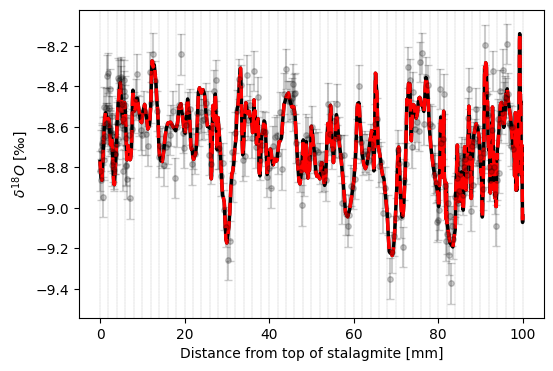

In [5]:
base_path = "../../../../data/"
# echam_path = os.path.join(base_path, "inputdata_250306A/ECHAM5_d18O_Dayu_Cave.xlsx") 

# df = pd.read_excel(echam_path)
# years = df["Year"].to_numpy()
# d18o = df["d18O"].to_numpy()
# d18o_filtered = df["Filtered d18O"].to_numpy()

# fig, ax = plt.subplots(figsize=(6, 4))
# ax.plot(years, d18o, color = "grey", linewidth = 1, label = "ECHAM5-wiso")
# ax.plot(years, d18o_filtered, color = "black", linewidth = 1, label = "ECHAM5-wiso, low-pass filtered")
# ax.legend(loc = "upper right")
# ax.set_xlabel("Year CE")
# ax.set_ylabel(r"$\delta^{18}O$ [‰]")
# plt.savefig("d18o_echam.jpg")
# plt.show()

depths = np.interp(data["d18ort"], model_ages_1[::-1], data["cs"][::-1], right = np.nan, left = np.nan)[::-1]
d18O_actual = np.interp(data["d18od"], depths, data["d18or"][::-1], right = np.nan, left = np.nan) + np.random.normal(loc = 0, scale = data["d18os"], size= len(data["d18od"]))
years_actual = np.interp(data["d18od"], data["cs"], model_ages_1, right = np.nan, left = np.nan)
years_c14_actual = np.interp(data["c14d"],data["cs"], model_ages_1, right = np.nan, left = np.nan)
print(d18O_actual)

fig, ax = plt.subplots(figsize=(6, 4))
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
ax.errorbar(
    data["d18od"], 
    d18O_actual, 
    data["d18os"]*np.ones(len(d18O_actual)), 
    color = "black",
    fmt='o',              # circular markers
    linestyle='none',     # no line between points
    capsize=3,
    markersize = 4,
    alpha = 0.2,
)
ax.plot(depths, data["d18or"][::-1], linewidth = 2.5, color = "black")
ax.plot(depths, data["d18or"][::-1], linewidth = 2.5, color = "red", linestyle = "dashed")
ax.set_xlabel("Distance from top of stalagmite [mm]")
ax.set_ylabel(r"$\delta^{18}O$ $[‰]$")
plt.show()

In [ ]:
init_nan = np.full(1, np.nan)
init_nans_c14 = np.full(1 + len(data["c14d"]), np.nan)
extra_nans = np.full(len(data["d18od"]), np.nan)

depths = np.concatenate((np.array([0]), data["c14d"], data["d18od"]))
true_ages = np.concatenate((np.array([data["th"]]), years_c14_actual, years_actual))
cal_c14_ages = np.concatenate((init_nan, data["c14"], extra_nans))
sigma_age = np.concatenate((init_nan, data["c14s"], extra_nans))
d18O = np.concatenate((init_nans_c14, d18O_actual))
sigma_d18O = np.concatenate((init_nans_c14, data["d18os"]))

df = pd.DataFrame({
    "depth": depths,
    "true_age": true_ages,
    "age": cal_c14_ages,
    "sigma_age": sigma_age,
    "d18O": d18O,
    "sigma_d18O": sigma_d18O
}) if not data["dn"] == "biw" else pd.DataFrame({
    "depth": depths,
    "true_age": true_ages,
    "age": cal_c14_ages,
    "sigma_age": sigma_age,
    "inc": d18O,
    "sigma_inc": sigma_d18O
})
print(df)

df.to_csv(
    os.path.join(base_path, name_map[data["dn"]], "data_other.txt"),
    sep="\t",
    index=False
)

np.save(f"{base_path}/{name_map[data["dn"]]}/true_sample.npy", samples_1)
#Maybe still something weird here

     depth     true_age     age  sigma_age      d18O  sigma_d18O
0     0.00  1983.000000     NaN        NaN       NaN         NaN
1     2.50  1969.661277  1970.0        0.5       NaN         NaN
2    27.75  1835.337229  1836.0        1.0       NaN         NaN
3    35.25  1787.163133  1787.0        1.0       NaN         NaN
4    54.00  1661.359386  1660.0        1.5       NaN         NaN
..     ...          ...     ...        ...       ...         ...
304   0.52  1980.618908     NaN        NaN -8.688549         0.1
305   0.36  1981.351552     NaN        NaN -8.681347         0.1
306   0.26  1981.809454     NaN        NaN -8.859811         0.1
307   0.16  1982.267356     NaN        NaN -8.715900         0.1
308   0.10  1982.542098     NaN        NaN -8.818741         0.1

[309 rows x 6 columns]


<function matplotlib.pyplot.show(close=None, block=None)>

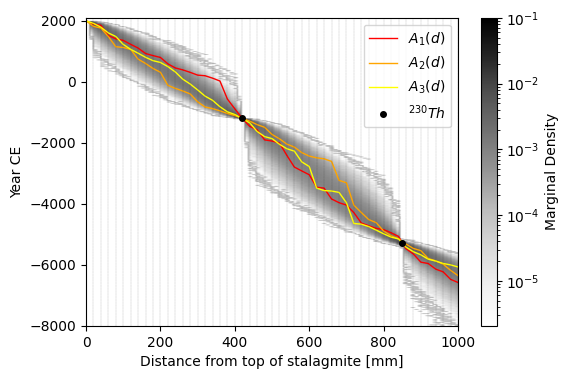

In [8]:
# flat_samples = samples.reshape(-1, samples.shape[-1])
# cumulative_sums = np.cumsum(flat_samples, axis=1) * data["dc"]
# zeros = np.zeros((*flat_samples.shape[:1], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
# model_ages = data["th"] - age_offsets

chain = 4
X = samples[chain].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 10
t_edges = np.arange(-8000, 2100 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 10
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)

im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")

ax.plot(
    data["cs"],
    model_ages_1,
    color='red',
    alpha=1,
    linewidth=1,
    label = r"$A_1(d)$"
)

ax.plot(
    data["cs"],
    model_ages_2,
    color='orange',
    alpha=1,
    linewidth=1,
    label = r"$A_2(d)$"
)

ax.plot(
    data["cs"],
    model_ages_3,
    color='yellow',
    alpha=1,
    linewidth=1,
    label = r"$A_3(d)$"
)

for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)
    

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(-8000, 2100)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/ad_samples.jpg")
plt.show


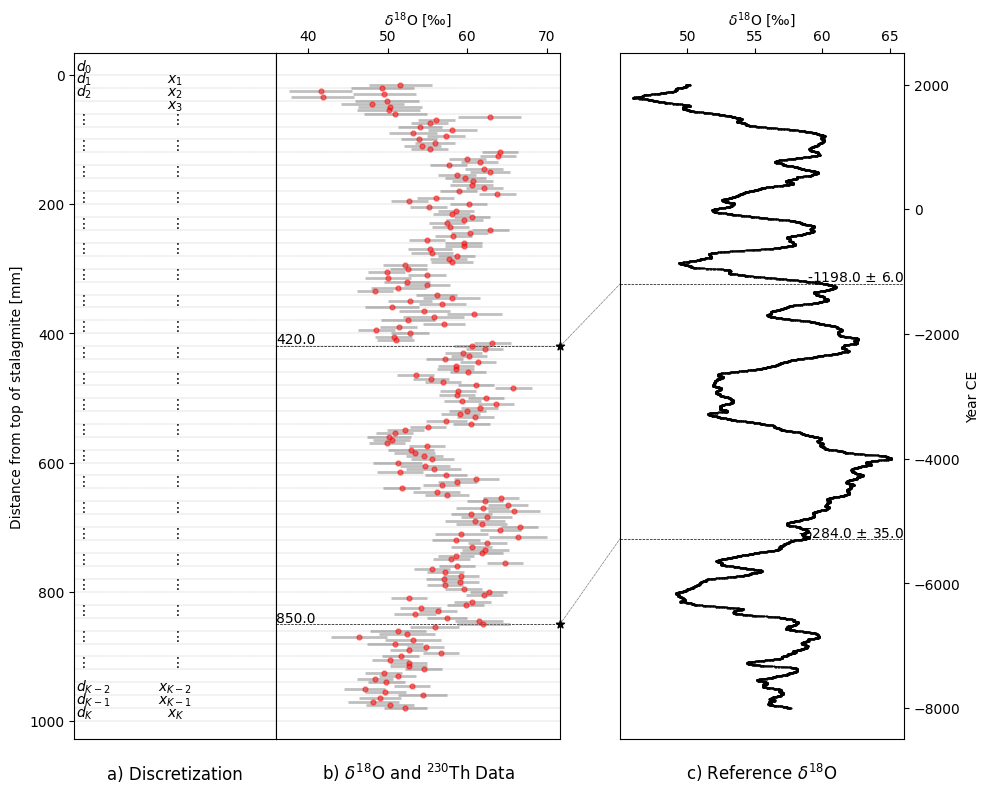

In [7]:
import matplotlib.transforms as mtransforms
from matplotlib.patches import ConnectionPatch

fig, (ax1, ax2, ax3) = plt.subplots(
    ncols=3,
    figsize=(10, 8),
    gridspec_kw={'width_ratios': [1, 2, 2]},
    sharey=False
)

ax1.sharey(ax2)

ax2.errorbar(
    d18O_actual, data["d18od"],
    xerr=data["d18os"],
    fmt='.',                # circle markers
    markersize=7,
    capsize=4,               # small caps on error bars
    elinewidth=2,          # thin error bar lines
    capthick=0,
    color='red',
    ecolor='gray',           # error bar color
    alpha=0.5,
    label="Measurements ± uncertainty"
)
ax2.xaxis.tick_top()
ax2.xaxis.set_label_position('top')
ax2.set_xlabel("$\\delta^{18}$O [‰]")
ax1.invert_yaxis()

extra_depths = data["c14d"]

ax2.scatter(
    [1]*len(extra_depths),   # x-position (right edge)
    extra_depths,
    marker='*',
    color='black',
    transform=ax2.get_yaxis_transform(),
    clip_on=False
)

for i, d in enumerate(data["c14d"]):
    ax2.axhline(y=d, color='k', linestyle='--', linewidth = 0.5, zorder=0)
    # ax1.axhline(y=d, color='r', linestyle='--', linewidth = 0.5, zorder=0)
    if i == len(data["c14"]) - 1:
        y = d + 2
    else:
        y = d
    ax2.text(
        x=ax2.get_xlim()[0] + 0.01,    # right end of x-axis
        y=y ,             # slightly above the line     
        s=f"{d}",          # text
        ha='left',            # align text to the right
        va='bottom',           # bottom of text at y + offset
        # fontsize=8
    )


ax3.plot(data["d18or"], data["d18ort"], color = "k", linewidth = 0.8)
ax3.plot(data["d18or"], data["d18ort"], '.', color = "k", markersize = 1)
# for i in range(config["nch"]):
#     variables = resampled_samples[i,:,:]
#     for j in range(len(variables)):
#         d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
#         plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

# plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
ax3.set_ylabel("Year CE")
ax3.set_xlabel("$\\delta^{18}$O [‰]")
ax3.xaxis.tick_top()
ax3.xaxis.set_label_position('top')

# Move y-axis to the right
ax3.yaxis.tick_right()                # Move tick marks to the right
ax3.yaxis.set_label_position("right") # Move y-axis label to the right
ax3.spines['right'].set_position(('outward', 0))  # Position the right spine

for i, d in enumerate(data["c14"]):
    ax3.axhline(y=d, color='k', linestyle='--', linewidth = 0.5, zorder=0)
    # ax1.axhline(y=d, color='r', linestyle='--', linewidth = 0.5, zorder=0)
    if i == len(data["c14"]) - 1:
        y = d - 25
    else:
        y = d
    ax3.text(
        x=ax3.get_xlim()[1] - 0.01,    # right end of x-axis
        y=y,             # slightly above the line     
        s=f"{d} $\\pm$ {data["c14s"][i]}",          # text
        ha='right',            # align text to the right
        va='bottom',           # bottom of text at y + offset
        # fontsize=8
    )

ax1.xaxis.set_visible(False)
ax1.set_ylabel("Distance from top of stalagmite [mm]")

for i, d in enumerate(data["cs"]):
    ax1.axhline(y=d, color='k', linestyle='--', linewidth = 0.1)
    ax2.axhline(y=d, color='k', linestyle='--', linewidth = 0.1)
    if (i>0 and i <=3):
            ax1.text(
                x=ax1.get_xlim()[0] + 0.5,    # center of x-axis
                y=d ,             # slightly above the line
                s=f"$x_{{{i}}}$",          # text
                ha='center',            # align text to the right
                va='bottom',           # bottom of text at y + offset
                # fontsize=8
            )

            ax1.text(
                x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
                y=data["cs"][i-1] ,             # slightly above the line
                s=f"$d_{{{i-1}}}$",          # text
                ha='left',            # align text to the right
                va='bottom',           # bottom of text at y + offset
                # fontsize=8
            )
    elif (i > data["N"] - 3 and i < data["N"]):
        ax1.text(
            x=ax1.get_xlim()[0] + 0.5,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$x_{{K-{data["N"] - i}}}$",          # text
            ha='center',            # align text to the right
            va='bottom',           # bottom of text at y + offset
        )
            
        ax1.text(
            x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
            y=data["cs"][i] ,             # slightly above the line
            s=f"$d_{{K-{data["N"] - i}}}$",          # text
            ha='left',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )# fontsize=8
    elif (i == data["N"]):
        ax1.text(
            x=ax1.get_xlim()[0] + 0.5,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$x_K$",          # text
            ha='center',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )

        ax1.text(
            x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
            y=data["cs"][i] ,             # slightly above the line
            s=f"$d_K$",          # text
            ha='left',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )# fontsize=8
    elif (i % 2 == 0 and i != 0):
        ax1.text(
            x=ax1.get_xlim()[0] + 0.5,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$\\vdots$",          # text
            ha='center',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )

        ax1.text(
            x=ax1.get_xlim()[0] + 0.01,    # right end of x-axis
            y=d ,             # slightly above the line
            s=f"$\\vdots$",          # text
            ha='left',            # align text to the right
            va='bottom',           # bottom of text at y + offset
            # fontsize=8
        )

plt.tight_layout(rect = [0, 0.05, 1, 1])
ax2.tick_params(axis='y', left=False, labelleft=False)
pos2 = ax2.get_position()
pos1 = ax1.get_position()
ax1.set_position([pos1.x0, pos2.y0, pos2.x0 - pos1.x0, pos2.height])

for i, d in enumerate(data["c14d"]):
    # Create a line connecting (xlim_max of ax2, depth) to (xlim_min of ax3, depth)
    con = ConnectionPatch(
        xyA=(ax2.get_xlim()[1], d), # Point in ax2 (right side)
        xyB=(ax3.get_xlim()[0], data["c14"][i]), # Point in ax3 (left side)
        coordsA="data", coordsB="data",
        axesA=ax2, axesB=ax3,
        color="black", linestyle="--", linewidth=0.5, alpha=0.5
    )
    fig.add_artist(con)

ax1.set_title("a) Discretization", y=-0.07)
ax2.set_title("b) $\\delta^{18}$O and $^{230}$Th Data", y=-0.07)
ax3.set_title("c) Reference $\\delta^{18}$O", y=-0.07)
plt.savefig(f"{output_dir}/fancy_fig_classic_new.jpg")
plt.show()

